In [ ]:
!pip -q install -U transformers datasets evaluate scikit-learn accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 18.7 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

candidates = [
    "SetFit/sms_spam",
    "sms_spam",
]

ds = None
for name in candidates:
    try:
        ds = load_dataset(name)
        print("Loaded:", name)
        print(ds)
        break
    except Exception as e:
        print("Failed:", name, "|", e)

assert ds is not None, "No dataset could be loaded"


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Failed: SetFit/sms_spam | Dataset 'SetFit/sms_spam' doesn't exist on the Hub or cannot be accessed.


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/359k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]

Loaded: sms_spam
DatasetDict({
    train: Dataset({
        features: ['sms', 'label'],
        num_rows: 5574
    })
})


In [ ]:
# Setting
SEED = 42
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 64

In [ ]:
SEED = 42

# 1) 80/20 split (train / temp)
split1 = ds["train"].train_test_split(
    test_size=0.2,
    seed=SEED,
    stratify_by_column="label",
)
train_ds = split1["train"]
temp_ds  = split1["test"]

# 2) 10/10 split (val / test) from temp
split2 = temp_ds.train_test_split(
    test_size=0.5,
    seed=SEED,
    stratify_by_column="label",
)
val_ds  = split2["train"]
test_ds = split2["test"]

print("sizes:", len(train_ds), len(val_ds), len(test_ds))


sizes: 4459 557 558


In [ ]:
# What: Import core libraries for training/evaluation with HuggingFace Trainer.
# Why: We keep all dependencies explicit to ensure reproducibility and easier debugging.

import numpy as np
import torch
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

# What: Disable Weights & Biases logging.
# Why: Avoid interactive prompts and keep training fully offline/reproducible.

import os
os.environ["WANDB_DISABLED"] = "true"

# What: Fix random seeds.
# Why: Helps reproduce results across runs (within the limits of GPU determinism).
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# What: Check GPU availability.
# Why: DistilBERT fine-tuning is significantly faster on GPU.
print("CUDA available:", torch.cuda.is_available())
print("Seed:", SEED)


CUDA available: True
Seed: 42


In [ ]:

# What: Load the tokenizer for DistilBERT and define the tokenization function.
# Why: Transformer models require tokenization into input_ids + attention_mask.

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128  # What: Truncation length. Why: SMS is short; 128 is sufficient and efficient.

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(batch):
    # What: Convert raw SMS text into token IDs and attention masks.
    # Why: Trainer expects tokenized features; padding is deferred to the data collator.
    return tokenizer(
        batch["sms"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH,
    )

print("Tokenizer loaded:", MODEL_NAME)
print("MAX_LENGTH:", MAX_LENGTH)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded: distilbert-base-uncased
MAX_LENGTH: 128


In [ ]:
# What: Tokenize datasets while keeping labels for Trainer.
# Why: Trainer requires a "labels" column to compute loss automatically.

def tokenize_and_keep_labels(ds):
    # Tokenize text
    tok_ds = ds.map(
        preprocess,
        batched=True,
        remove_columns=["sms"],  # Remove only raw text
    )

    # Rename label column to "labels" (Trainer convention)
    if "label" in tok_ds.column_names:
        tok_ds = tok_ds.rename_column("label", "labels")

    return tok_ds

train_tok = tokenize_and_keep_labels(train_ds)
val_tok   = tokenize_and_keep_labels(val_ds)
test_tok  = tokenize_and_keep_labels(test_ds)

print("Tokenized columns:", train_tok.column_names)


Map:   0%|          | 0/4459 [00:00<?, ? examples/s]

Map:   0%|          | 0/557 [00:00<?, ? examples/s]

Map:   0%|          | 0/558 [00:00<?, ? examples/s]

Tokenized columns: ['labels', 'input_ids', 'attention_mask']


In [ ]:
# What: Load a pre-trained DistilBERT with a classification head.
# Why: We fine-tune the model end-to-end for binary classification (ham=0, spam=1).

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("Model loaded:", MODEL_NAME)
print("num_labels:", model.config.num_labels)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: distilbert-base-uncased
num_labels: 2


In [ ]:
# What: Define evaluation metrics.
# Why: We must match the baseline metrics exactly (accuracy/precision/recall/f1).
# Note: We use binary averaging assuming spam=1 is the positive class.

accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    # What: Convert logits -> predicted label, then compute metrics.
    # Why: Trainer passes logits and labels; we need discrete predictions for sklearn-style metrics.
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision.compute(predictions=preds, references=labels, average="binary")["precision"],
        "recall": recall.compute(predictions=preds, references=labels, average="binary")["recall"],
        "f1": f1.compute(predictions=preds, references=labels, average="binary")["f1"],
    }

print("Metrics ready: accuracy / precision / recall / f1 (binary, spam=1)")

Metrics ready: accuracy / precision / recall / f1 (binary, spam=1)


In [ ]:
# What: Build TrainingArguments in a version-robust way.
# Why: Some transformers versions renamed arguments (e.g., evaluation_strategy -> eval_strategy).

import inspect
from transformers import TrainingArguments

def make_training_args(**kwargs):
    # What: Filter kwargs by the actual TrainingArguments signature.
    # Why: Avoid "unexpected keyword argument" errors across transformers versions.
    sig = inspect.signature(TrainingArguments.__init__)
    valid = set(sig.parameters.keys())
    filtered = {k: v for k, v in kwargs.items() if k in valid}
    dropped = sorted([k for k in kwargs.keys() if k not in valid])

    if dropped:
        print("Dropped unsupported TrainingArguments keys:", dropped)
    return TrainingArguments(**filtered)

# What: Prepare argument dict with fallbacks for renamed keys.
# Why: Use whichever key exists in your installed transformers version.
args_dict = dict(
    output_dir="./results/transformer",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_strategy="epoch",
    save_total_limit=1,
    seed=SEED,
)

# What: Add evaluation/save strategy with compatibility for renamed arguments.
# Why: Some versions use evaluation_strategy/save_strategy, others use eval_strategy/save_strategy.
sig_keys = set(inspect.signature(TrainingArguments.__init__).parameters.keys())

if "evaluation_strategy" in sig_keys:
    args_dict["evaluation_strategy"] = "epoch"
elif "eval_strategy" in sig_keys:
    args_dict["eval_strategy"] = "epoch"

if "save_strategy" in sig_keys:
    args_dict["save_strategy"] = "epoch"

training_args = make_training_args(**args_dict)

print("TrainingArguments ready.")

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


TrainingArguments ready.


In [ ]:
# What: Create Trainer with model, data, collator, and metric function.
# Why: Trainer handles training loop, evaluation loop, checkpointing, and logging.

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],  # What: Stop if val metric stops improving.
)

print("Trainer ready.")


/tmp/ipython-input-3066054284.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Trainer ready.


In [ ]:
# What: Run fine-tuning.
# Why: This produces a comparable model to baseline, using identical data split and metrics.

train_result = trainer.train()
print("Training finished.")


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.145200,0.029711,0.991023,0.972603,0.959459,0.965986
2,0.022900,0.023627,0.994614,0.986301,0.972973,0.979592
3,0.011100,0.030055,0.992819,0.972973,0.972973,0.972973


Training finished.


In [ ]:
# What: Evaluate on the held-out test set.
# Why: Test metrics are used for the final model comparison in the report.

test_metrics = trainer.evaluate(test_tok)

print("Test metrics:")
for k, v in test_metrics.items():
    if k.startswith("eval_"):
        print(f"{k.replace('eval_', '')}: {v}")


Test metrics:
loss: 0.06956435739994049
accuracy: 0.985663082437276
precision: 0.958904109589041
recall: 0.9333333333333333
f1: 0.9459459459459459
runtime: 1.1156
samples_per_second: 500.185
steps_per_second: 31.374


In [ ]:
# What: Compute confusion matrix on the test set.
# Why: Provides an interpretable error breakdown (FP/FN), required for report.

from sklearn.metrics import confusion_matrix

pred_out = trainer.predict(test_tok)
y_true = pred_out.label_ids
y_pred = np.argmax(pred_out.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[480   3]
 [  5  70]]


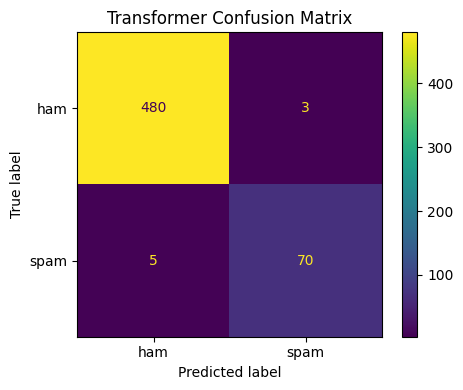

In [ ]:
# What: Display confusion matrix as a figure for the Transformer model.
# Why: Required for the report and for fair visual comparison with the baseline.

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Assumes you already ran:
# pred_out = trainer.predict(test_tok)
# y_true = pred_out.label_ids
# y_pred = np.argmax(pred_out.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d")
ax.set_title("Transformer Confusion Matrix")
plt.tight_layout()
plt.show()


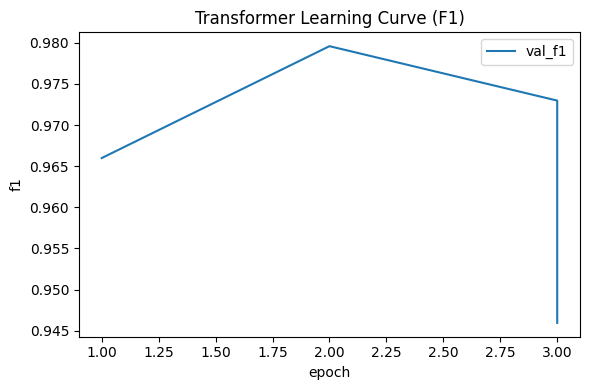

In [ ]:
# What: Plot validation F1 over epochs from Trainer logs.
# Why: Learning curves are required artifacts; Trainer stores logs in state.log_history.

import pandas as pd
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
df_logs = pd.DataFrame(log_history)

# Keep only rows with eval_f1 and epoch
df_f1 = df_logs.dropna(subset=["epoch"]).copy()
if "eval_f1" not in df_f1.columns:
    raise ValueError(f"eval_f1 not found. Available columns: {df_logs.columns.tolist()}")

df_f1 = df_f1.dropna(subset=["eval_f1"])

plt.figure(figsize=(6, 4))
plt.plot(df_f1["epoch"], df_f1["eval_f1"], label="val_f1")
plt.xlabel("epoch")
plt.ylabel("f1")
plt.title("Transformer Learning Curve (F1)")
plt.legend()
plt.tight_layout()
plt.show()


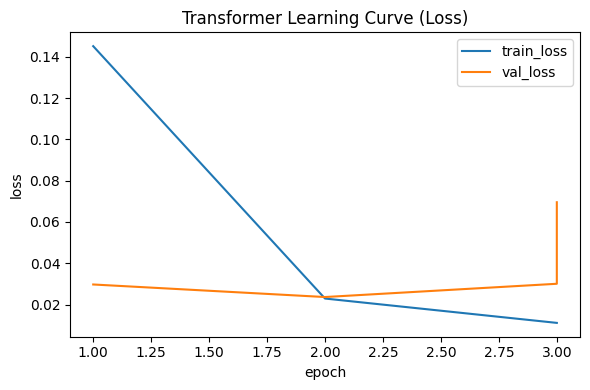

In [ ]:
# What: Plot training loss and validation loss over epochs from Trainer logs.
# Why: Loss curves help explain training dynamics and overfitting/underfitting trends.

import pandas as pd
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
df_logs = pd.DataFrame(log_history).dropna(subset=["epoch"]).copy()

# Trainer typically logs "loss" (train) and "eval_loss" (val)
has_train_loss = "loss" in df_logs.columns
has_val_loss = "eval_loss" in df_logs.columns

if not has_train_loss and not has_val_loss:
    raise ValueError(f"No loss columns found. Available columns: {df_logs.columns.tolist()}")

plt.figure(figsize=(6, 4))
if has_train_loss:
    # Train loss is logged per logging step; for epoch-level plot, keep non-null values
    df_train = df_logs.dropna(subset=["loss"])
    plt.plot(df_train["epoch"], df_train["loss"], label="train_loss")
if has_val_loss:
    df_val = df_logs.dropna(subset=["eval_loss"])
    plt.plot(df_val["epoch"], df_val["eval_loss"], label="val_loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Transformer Learning Curve (Loss)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# What: Print representative false positives and false negatives with raw SMS text.
# Why: Required for report-level error analysis and comparison with baseline examples.

import pandas as pd

texts_test = test_ds["sms"]  # Raw texts aligned with test_ds order
assert len(texts_test) == len(y_true) == len(y_pred), "Length mismatch in test outputs."

df_err = pd.DataFrame({
    "text": texts_test,
    "y_true": y_true,
    "y_pred": y_pred,
})

fp = df_err[(df_err.y_true == 0) & (df_err.y_pred == 1)]
fn = df_err[(df_err.y_true == 1) & (df_err.y_pred == 0)]

fp = fp.drop_duplicates(subset=["text"])
fn = fn.drop_duplicates(subset=["text"])

print("=== False Positives (Ham -> Spam) ===")
for _, row in fp.head(3).iterrows():
    print(f"\nText: {row['text']}")

print("\n=== False Negatives (Spam -> Ham) ===")
for _, row in fn.head(3).iterrows():
    print(f"\nText: {row['text']}")


=== False Positives (Ham -> Spam) ===

Text: Message:some text missing* Sender:Name Missing* *Number Missing *Sent:Date missing *Missing U a lot thats y everything is missing sent via fullonsms.com


Text: MY NO. IN LUTON 0125698789 RING ME IF UR AROUND! H*


=== False Negatives (Spam -> Ham) ===

Text: Do you ever notice that when you're driving, anyone going slower than you is an idiot and everyone driving faster than you is a maniac?


Text: How come it takes so little time for a child who is afraid of the dark to become a teenager who wants to stay out all night?


Text: accordingly. I repeat, just text the word ok on your mobile phone and send

